# 📘 Taller Evaluativo (20%) - Análisis de Portafolio
### Curso: Ingeniería Financiera / Programación  
### Herramienta: Google Colab  
---
### 🎯 Objetivo
Este taller busca que comprendas qué es un análisis de portafolio, cómo se calculan y analizan sus métricas (rentabilidad, riesgo y correlación), y cómo se interpreta el resultado para tomar decisiones de inversión.

👉 **Importante:** No basta con ejecutar el código. Debes **completar los espacios en blanco**, responder las **preguntas de investigación** y redactar un **análisis final**.

## 1. Importación de librerías
Primero, importa las librerías necesarias para trabajar con datos financieros.

In [ ]:
# COMPLETAR: importa las librerías necesarias (yfinance, pandas, numpy, matplotlib, seaborn)
# Ejemplo: import yfinance as yf

# COMPLETAR AQUÍ

In [13]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Descarga de datos
Usa `yfinance` para descargar los precios de **Google (GOOG)**, **Amazon (AMZN)** y **Microsoft (MSFT)** durante los últimos 3 años. Utiliza la columna `Adj Close`.

🔎 **Pregunta:** ¿Por qué es más adecuado usar `Adj Close` que `Close` para un análisis financiero?

**Respuesta:** En un análisis financiero, es más adecuado usar Adjusted Close (Adj Close) en lugar de Close porque el “Close” refleja solo el precio de cierre diario de la acción, mientras que el “Adj Close” incorpora ajustes que corrigen el precio histórico para reflejar de forma realista la rentabilidad que habría recibido un inversionista.

In [21]:
# COMPLETAR: descarga los precios de las acciones usando yf.download

acciones = ["GOOG", "AMZN", "MSFT"]
datos = yf.download(tickers=acciones, period="3y")["Close"]
datos.head() # Veo los primeros 5 datos

/tmp/ipython-input-2716751308.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  datos = yf.download(tickers=acciones, period="3y")["Close"]
[*********************100%***********************]  3 of 3 completed


Ticker,AMZN,GOOG,MSFT
Date,,,
2022-09-19,124.660004,103.144157,238.584915
2022-09-20,122.190002,101.137878,236.565125
2022-09-21,118.540001,99.330261,233.150070
2022-09-22,117.309998,99.886452,235.130798
2022-09-23,113.779999,98.495964,232.145081


In [20]:
datos.tail() # Veo los últimos 5 datos

Ticker,AMZN,GOOG,MSFT
Date,,,
2025-09-12,228.149994,241.380005,509.899994
2025-09-15,231.429993,251.759995,515.359985
2025-09-16,234.050003,251.419998,509.040009
2025-09-17,231.619995,249.850006,510.019989
2025-09-18,231.229996,252.330002,508.450012


## 3. Visualización de precios
Grafica en una misma figura la evolución de los precios de cierre ajustados de las tres acciones.

🔎 **Pregunta:** ¿Cuál de las tres acciones muestra mayor crecimiento en estos 3 años?

**Respuesta:** La acción que muestra mayor crecimiento es GOOG

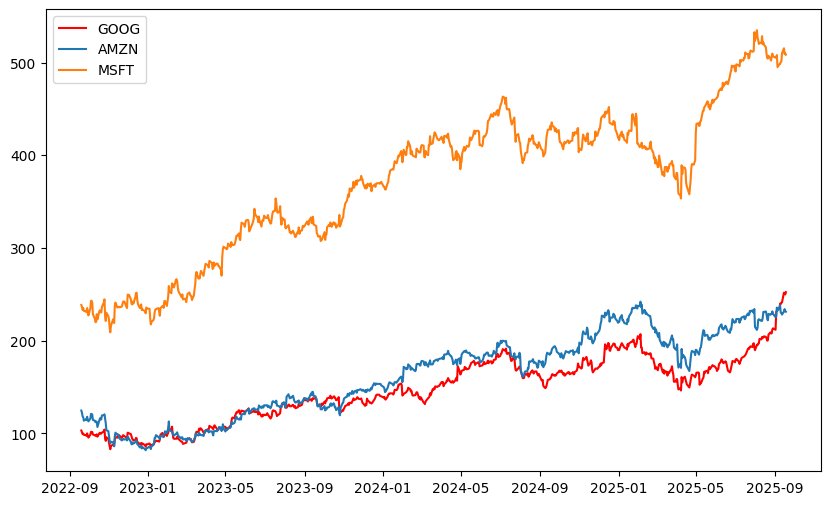

Crecimiento en los últimos 3 años:
Ticker
AMZN     85.49 %
GOOG    144.64 %
MSFT    113.11 %
dtype: object


In [32]:
# COMPLETAR: grafica las tres series de precios en una sola gráfica

plt.figure(figsize=(10,6))
plt.plot(datos["GOOG"], label="GOOG",color="red")
plt.plot(datos["AMZN"], label="AMZN")
plt.plot(datos["MSFT"], label="MSFT")
plt.legend()
plt.show()


crecimiento = (datos.iloc[-1] / datos.iloc[0] - 1) * 100
crecimiento = crecimiento.round(2).astype(str) + " %"

print("Crecimiento en los últimos 3 años:")
print(crecimiento)

In [36]:
import plotly.express as px

In [38]:
fig = px.line(datos)
fig.show()

## 4. Rentabilidades
Calcula las **rentabilidades logarítmicas diarias** y grafícalas.

🔎 **Pregunta:** ¿Qué diferencias encuentras entre observar precios y observar rentabilidades?

**Respuesta:** La diferencia entre observar precios y observar rentabilidades es que los precios muestran el valor absoluto de una acción en el tiempo, pero no permiten comparaciones directas entre activos, mientras que las rentabilidades expresan los cambios relativos (en porcentaje o logaritmo) y son la medida adecuada para analizar crecimiento, riesgo y desempeño de inversión. En resumen, los precios dicen cuánto cuesta un activo, y las rentabilidades dicen cuánto se gana o se pierde al invertir en él.

Ticker          AMZN      GOOG      MSFT
Date                                    
2022-09-19       NaN       NaN       NaN
2022-09-20 -0.020013 -0.019643 -0.008502
2022-09-21 -0.030327 -0.018034 -0.014541
2022-09-22 -0.010430  0.005584  0.008460
2022-09-23 -0.030553 -0.014018 -0.012779
...              ...       ...       ...
2025-09-12 -0.007859  0.002489  0.017589
2025-09-15  0.014274  0.042104  0.010651
2025-09-16  0.011257 -0.001351 -0.012339
2025-09-17 -0.010437 -0.006264  0.001923
2025-09-18 -0.001685  0.009877 -0.003083

[753 rows x 3 columns]


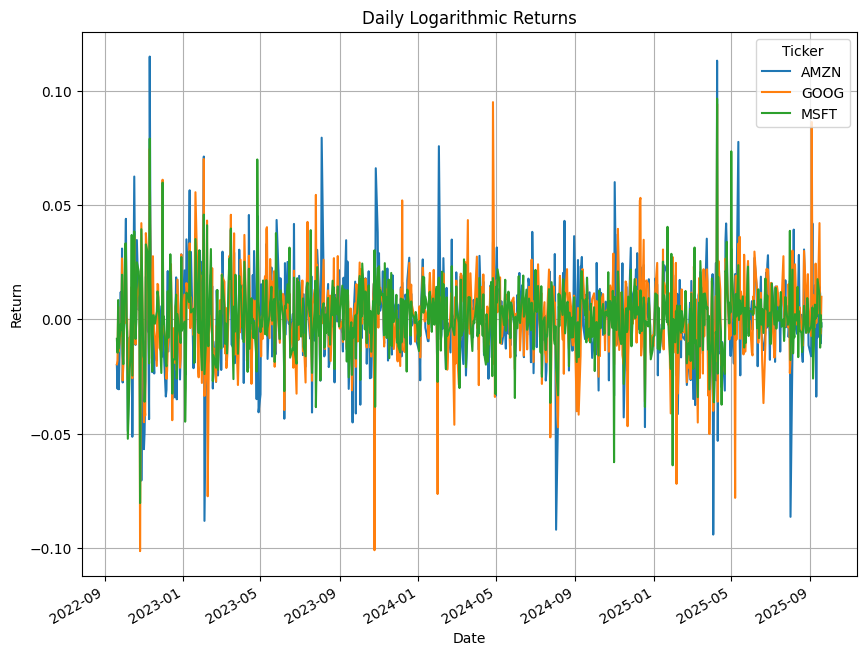

In [44]:
# COMPLETAR: calcula los rendimientos logarítmicos

rendimientos = np.log(datos / datos.shift(1))
rendimientos.head()
print(rendimientos)

# Graficar
plt.figure(figsize=(10, 8))
rendimientos.plot(ax=plt.gca()) # Use the current axes
plt.title('Daily Logarithmic Returns')
plt.xlabel('Date')
plt.ylabel('Return')
plt.grid(True)
plt.show()

## 5. Medidas estadísticas
Calcula la **rentabilidad promedio** y la **volatilidad (desviación estándar)** de cada acción.

🔎 **Pregunta:** ¿Cuál acción es más riesgosa? ¿Cuál ofrece mayor retorno?

**Respuesta:** La acción más riesgosa es Amazon y la que ofrece más retorno es Google

In [57]:
media = rendimientos.mean()
volatilidad = rendimientos.std()

print("Rentabilidad promedio diaria:")
print(media)
print("\nVolatilidad diaria:")
print(volatilidad)

resumen = pd.DataFrame({
    "Rentabilidad promedio diaria": media.round(4),
    "Volatilidad diaria": volatilidad.round(4)
})

accion_mas_retorno = resumen["Rentabilidad promedio diaria"].idxmax()
accion_mas_riesgo  = resumen["Volatilidad diaria"].idxmax()
print("\naccion_mas_retorno")
print(accion_mas_retorno)
print("\naccion_mas_riesgo")
print(accion_mas_riesgo)

Rentabilidad promedio diaria:
Ticker
AMZN    0.000822
GOOG    0.001190
MSFT    0.001006
dtype: float64

Volatilidad diaria:
Ticker
AMZN    0.021280
GOOG    0.019836
MSFT    0.015977
dtype: float64

accion_mas_retorno
GOOG

accion_mas_riesgo
AMZN


## 6. Correlación entre activos
Calcula y grafica la matriz de correlación entre las acciones.

🔎 **Pregunta:** ¿Qué significa que dos acciones tengan una correlación cercana a 1? ¿Y cercana a 0 o negativa?

**Respuesta:** Cuando dos acciones tienen una correlación cercana a 1 signfica que se casi igual, si es cercana a cero es porque no hay una relación clara y si es negativa significa que se mueven en direcciones opuestas.

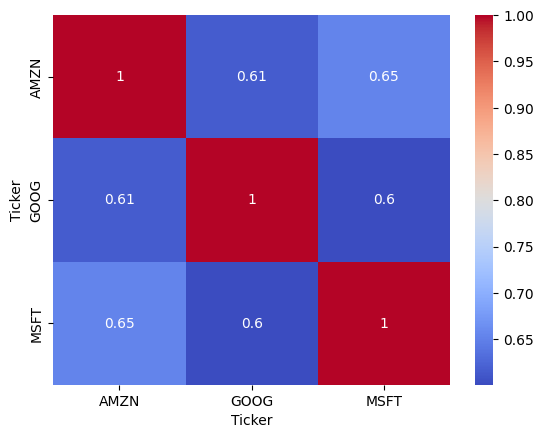

In [60]:
correlacion = rendimientos.corr()
sns.heatmap(correlacion, annot=True, cmap="coolwarm")
plt.show()


## 7. Portafolio simulado
Supón un portafolio con la siguiente distribución:
- 40% Google
- 30% Amazon
- 30% Microsoft

Calcula el **retorno esperado** y la **volatilidad del portafolio**.

🔎 **Preguntas:**
1. ¿Cómo interpretas el retorno esperado del portafolio?
2. ¿Qué efecto tuvo la diversificación sobre la volatilidad respecto a invertir en una sola acción?

**Respuestas:**
1. El retorno esperado indica la ganancia promedio del portafolio considerando la distribución 40% Google, 30% Amazon y 30% Microsoft. En este caso equivale a 0.0987% diario, cercano a un 24.8% anualizado, lo que refleja un potencial atractivo de rentabilidad al combinar los tres activos
2. La diversificación redujo la volatilidad respecto a invertir en una sola acción, especialmente en Amazon que era la más riesgosa. Al no estar perfectamente correlacionadas, las acciones compensan parte de sus fluctuaciones, logrando un riesgo menor sin sacrificar retorno.

In [74]:
# COMPLETAR: cálculo del retorno y riesgo del portafolio

pesos = np.array([0.4, 0.3, 0.3])
retorno_portafolio = np.dot(rendimientos.mean(), pesos)
volatilidad_portafolio = np.sqrt(np.dot(pesos.T, np.dot(rendimientos.cov(), pesos)))
print("Retorno esperado (diario):", round(retorno_portafolio, 6))
print("Volatilidad (diaria):", round(volatilidad_portafolio, 6))
retorno_anual = retorno_portafolio * 252
volatilidad_anual = volatilidad_portafolio * np.sqrt(252)
print("Retorno_anual:",round(retorno_anual,6))
print("Volatilidad anual:",round(volatilidad_anual, 6))


Retorno esperado (diario): 0.000987
Volatilidad (diaria): 0.016754
Retorno_anual: 0.248818
Volatilidad anual: 0.265961


## ✍️ 8. Conclusión final
Redacta un análisis completo del portafolio respondiendo:
- ¿Qué acción fue más rentable y cuál más riesgosa?
**Respuesta:** la acción más rentable es google y la acción más riesgosa es amazon
- ¿Qué tan correlacionadas están las acciones?
**Respuesta:** No están perfectamente y tienen una correlación positiva moderada, lo cual es bueno para el portafolio porque brinda un poco de diversificación.
- ¿Qué aportó la diversificación al portafolio?
**Respuesta:** La diversificación redujo el riesgo del portafolio al compensar las fluctuaciones de cada acción, logrando menor volatilidad sin perder retorno.
- Si fueras un inversionista, ¿invertirías en este portafolio? Justifica tu respuesta.
**Respuesta:** Sí, invertiría en este portafolio porque ofrece buen retorno esperado y menor riesgo gracias a la diversificación, aunque dependería del perfil de riesgo del inversionista.